In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import userdata

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
学習データのサイズ: (1460, 81)
テストデータのサイズ: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


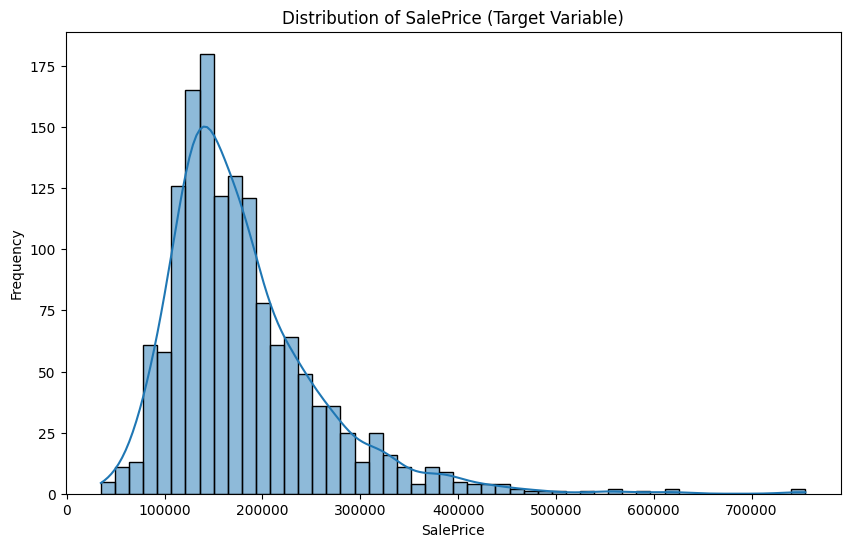

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip -o house-prices-advanced-regression-techniques.zip

# データの読み込み
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# データの全体像を確認
print(f"学習データのサイズ: {train_df.shape}")
print(f"テストデータのサイズ: {test_df.shape}")
display(train_df.head())

# 目的変数の分布を可視化
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice (Target Variable)')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

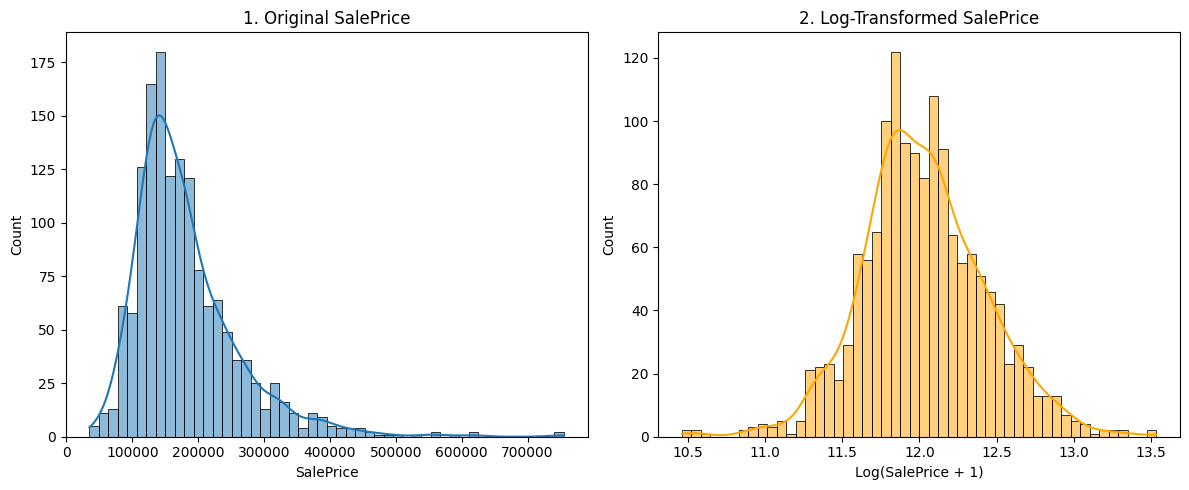

In [25]:
import numpy as np

plt.figure(figsize=(12, 5))

# 変換前
plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True, bins=50)
plt.title('1. Original SalePrice')
plt.xlabel('SalePrice')

# 対数変換の実行
train_df['SalePrice_Log'] = np.log1p(train_df['SalePrice'])

# 変換後
plt.subplot(1, 2, 2)
sns.histplot(train_df['SalePrice_Log'], kde=True, bins=50, color='orange')
plt.title('2. Log-Transformed SalePrice')
plt.xlabel('Log(SalePrice + 1)')

plt.tight_layout()
plt.show()

,Missing Ratio (%)
PoolQC,99.52 %
MiscFeature,96.30 %
Alley,93.77 %
Fence,80.75 %
MasVnrType,59.73 %
FireplaceQu,47.26 %
LotFrontage,17.74 %
GarageType,5.55 %
GarageYrBlt,5.55 %
GarageFinish,5.55 %


/tmp/ipykernel_430/1349511500.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentage.index, y=missing_percentage, palette="viridis")


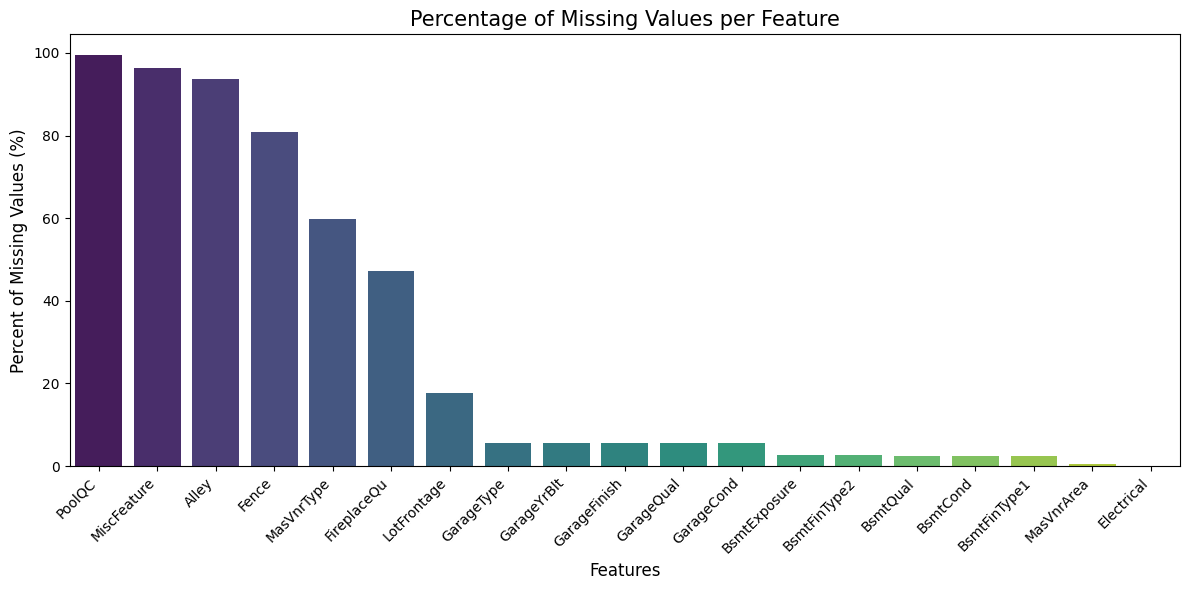

In [26]:
# 欠損値の数を計算し、1つ以上欠損がある変数だけを抽出
missing_counts = train_df.isnull().sum()
missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)

# 欠損値の割合を計算
missing_percentage = (missing_features / len(train_df)) * 100

missing_data = pd.DataFrame({'Missing Ratio (%)': missing_percentage})
display(missing_data.head(20).style.format("{:.2f} %"))

# 可視化
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Missing Values per Feature', fontsize=15)
plt.ylabel('Percent of Missing Values (%)', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_430/2704997627.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='LotFrontage', data=train_df, order=median_order, palette="muted")


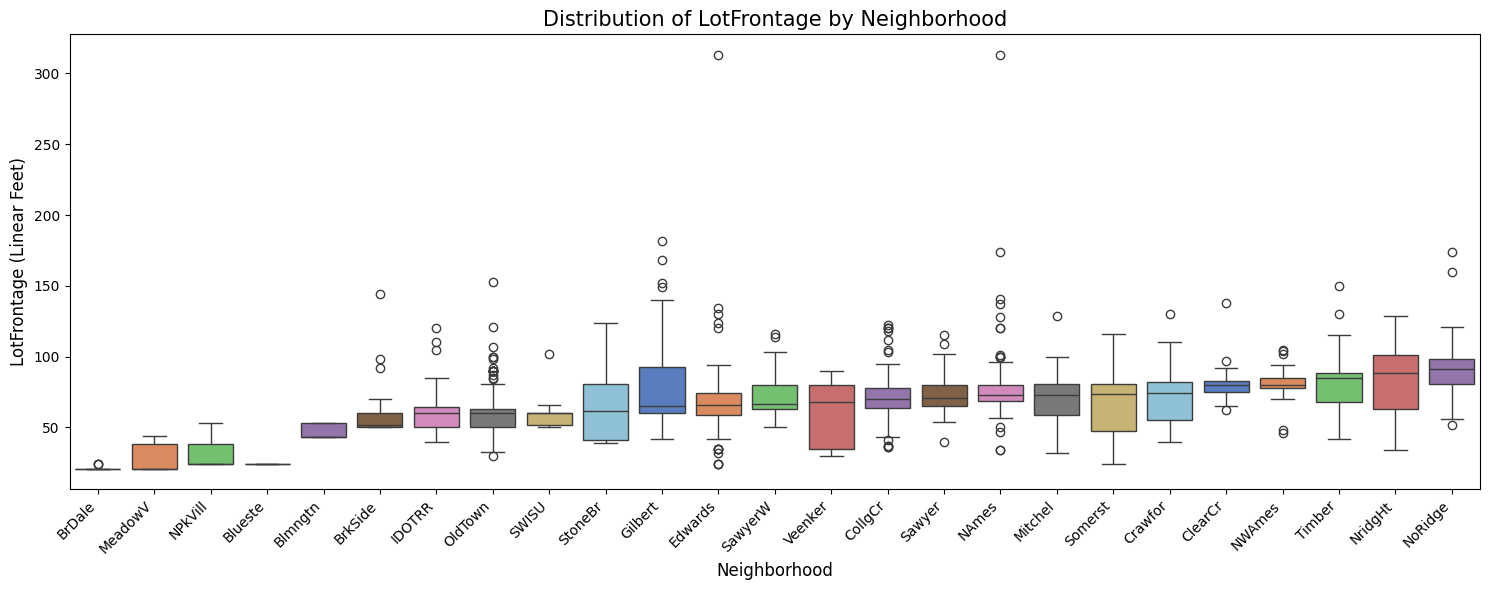

In [27]:
plt.figure(figsize=(15, 6))

# 各NeighborhoodにおけるLotFrontageの中央値を計算し、小さい順に並び替える
median_order = train_df.groupby('Neighborhood')['LotFrontage'].median().sort_values().index

# 可視化
sns.boxplot(x='Neighborhood', y='LotFrontage', data=train_df, order=median_order, palette="muted")

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Distribution of LotFrontage by Neighborhood', fontsize=15)
plt.ylabel('LotFrontage (Linear Feet)', fontsize=12)
plt.xlabel('Neighborhood', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# カテゴリ変数：NAを 'None' (設備なし) で補完
cols_fillna_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_fillna_none:
    train_df[col] = train_df[col].fillna('None')
    test_df[col] = test_df[col].fillna('None')

# 数値変数：NAを 0 (設備なし) で補完
cols_fillna_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]
for col in cols_fillna_zero:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

# LotFrontage：近隣(Neighborhood)グループの中央値で補完
train_df['LotFrontage'] = train_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_df['LotFrontage'] = test_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 最頻値で補完
cols_fillna_mode = [
    'Electrical', 'MSZoning', 'Utilities', 'Exterior1st',
    'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType'
]
for col in cols_fillna_mode:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

print(f"Trainデータの残りの欠損値数: {train_df.drop('SalePrice', axis=1).isnull().sum().max()}")
print(f"Testデータの残りの欠損値数: {test_df.isnull().sum().max()}")

Trainデータの残りの欠損値数: 0
Testデータの残りの欠損値数: 0


GrLivAreaとSalePrice_Logの相関:
   相関係数 r = 0.7009 (p値 = 3.06e-216)
TotalSF (新規作成)とSalePrice_Logの相関:
   相関係数 r = 0.7773 (p値 = 9.93e-296)


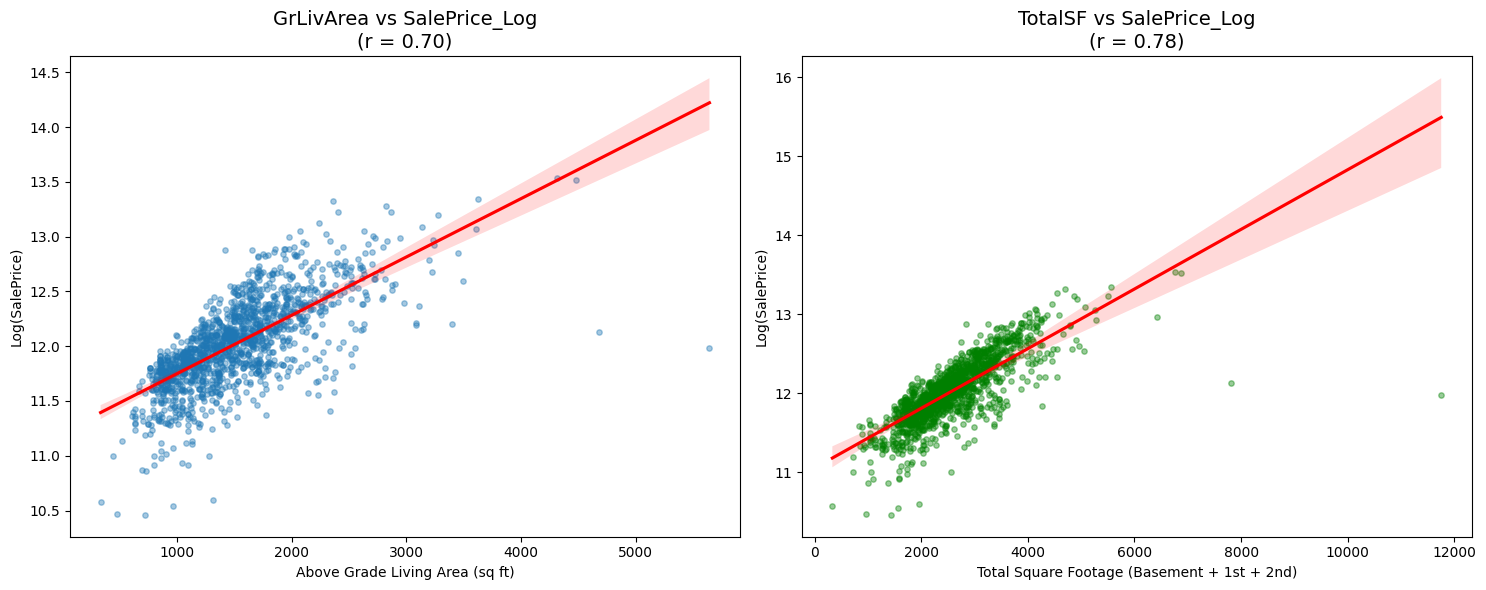

In [29]:
from scipy import stats

# 総面積 (TotalSF)の作成
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']
test_df['TotalSF'] = test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF']

# 統計検定（ピアソンの相関係数とp値の計算）
corr_grliv, p_grliv = stats.pearsonr(train_df['GrLivArea'], train_df['SalePrice_Log'])
corr_totalsf, p_totalsf = stats.pearsonr(train_df['TotalSF'], train_df['SalePrice_Log'])

print(f"GrLivAreaとSalePrice_Logの相関:")
print(f"   相関係数 r = {corr_grliv:.4f} (p値 = {p_grliv:.2e})")
print(f"TotalSF (新規作成)とSalePrice_Logの相関:")
print(f"   相関係数 r = {corr_totalsf:.4f} (p値 = {p_totalsf:.2e})")

# 視覚的な根拠
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 既存の地上面積
sns.regplot(x='GrLivArea', y='SalePrice_Log', data=train_df, ax=axes[0],
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
axes[0].set_title(f'GrLivArea vs SalePrice_Log\n(r = {corr_grliv:.2f})', fontsize=14)
axes[0].set_xlabel('Above Grade Living Area (sq ft)')
axes[0].set_ylabel('Log(SalePrice)')

# 新規作成した総面積
sns.regplot(x='TotalSF', y='SalePrice_Log', data=train_df, ax=axes[1],
            scatter_kws={'alpha':0.4, 's':15, 'color':'green'}, line_kws={'color':'red'})
axes[1].set_title(f'TotalSF vs SalePrice_Log\n(r = {corr_totalsf:.2f})', fontsize=14)
axes[1].set_xlabel('Total Square Footage (Basement + 1st + 2nd)')
axes[1].set_ylabel('Log(SalePrice)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_430/2313380154.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KitchenQual', y='SalePrice_Log', data=train_df, order=order, palette="coolwarm")


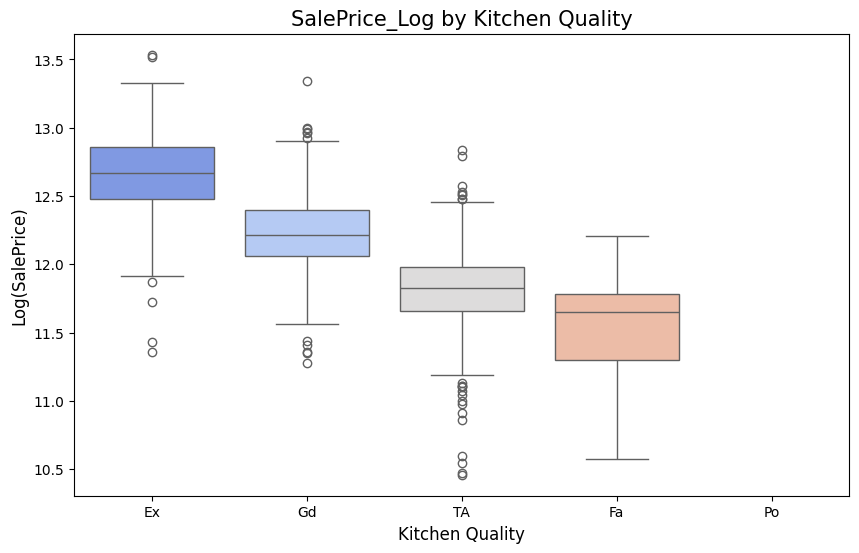

KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64


In [30]:
# KitchenQual（キッチンの品質）と価格の関係
plt.figure(figsize=(10, 6))

order = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
sns.boxplot(x='KitchenQual', y='SalePrice_Log', data=train_df, order=order, palette="coolwarm")
plt.title('SalePrice_Log by Kitchen Quality', fontsize=15)
plt.xlabel('Kitchen Quality', fontsize=12)
plt.ylabel('Log(SalePrice)', fontsize=12)
plt.show()

# 順序尺度のマッピング辞書を作成
qual_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

# 同じ評価基準を持つ列をリストアップ
qual_columns = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond'
]

for col in qual_columns:
    train_df[col] = train_df[col].map(qual_mapping).fillna(0).astype(int)
    test_df[col] = test_df[col].map(qual_mapping).fillna(0).astype(int)

print(train_df['KitchenQual'].value_counts())

In [31]:
y_train = train_df['SalePrice_Log']
train_features = train_df.drop(['SalePrice', 'SalePrice_Log', 'Id'], axis=1)
test_features = test_df.drop(['Id'], axis=1)

# 残っている文字データをダミー変数化
train_features = pd.get_dummies(train_features)
test_features = pd.get_dummies(test_features)

# TrainとTestの列を揃える
# join='inner' にすることで、両方に共通して存在する列だけを残す
train_features, test_features = train_features.align(test_features, join='inner', axis=1)

X_train = train_features
X_test = test_features

print(f"学習データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")

学習データ: (1460, 249)
テストデータ: (1459, 249)


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

# 交差検証
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 結果を保存する辞書
model_results = {}

# 線形回帰
pipeline_lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
# 評価指標は負のRMSE
scores_lr = cross_val_score(pipeline_lr, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf)
model_results['1. Linear Regression'] = -scores_lr.mean()

# リッジ
pipeline_ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
param_grid_ridge = {'ridge__alpha': [1.0, 10.0, 50.0, 100.0, 200.0, 300.0]}
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, scoring='neg_root_mean_squared_error', cv=kf)
grid_ridge.fit(X_train, y_train)
model_results['2. Ridge'] = -grid_ridge.best_score_
best_ridge_alpha = grid_ridge.best_params_['ridge__alpha']

# ラッソ
pipeline_lasso = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=5000))])
param_grid_lasso = {'lasso__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]}
grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, scoring='neg_root_mean_squared_error', cv=kf)
grid_lasso.fit(X_train, y_train)
model_results['3. Lasso'] = -grid_lasso.best_score_
best_lasso_alpha = grid_lasso.best_params_['lasso__alpha']

# Elastic Net
pipeline_en = Pipeline([('scaler', StandardScaler()), ('en', ElasticNet(max_iter=5000))])
param_grid_en = {
    'en__alpha': [0.0005, 0.001, 0.005, 0.01, 0.15, 0.20],
    'en__l1_ratio': [0.1, 0.5, 0.9]
}
grid_en = GridSearchCV(pipeline_en, param_grid_en, scoring='neg_root_mean_squared_error', cv=kf)
grid_en.fit(X_train, y_train)
model_results['4. ElasticNet'] = -grid_en.best_score_

# 結果の表示
for model_name, rmse in sorted(model_results.items(), key=lambda x: x[1]):
    print(f"{model_name:<20} : {rmse:.5f}")

print(f"Ridge Alpha     : {best_ridge_alpha}")
print(f"Lasso Alpha     : {best_lasso_alpha}")
print(f"ElasticNet Params: {grid_en.best_params_}")

2. Ridge             : 0.14778
4. ElasticNet        : 0.15160
3. Lasso             : 0.15190
1. Linear Regression : 0.21190
Ridge Alpha     : 300.0
Lasso Alpha     : 0.005
ElasticNet Params: {'en__alpha': 0.01, 'en__l1_ratio': 0.5}


/tmp/ipykernel_430/1104416228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top20_features, palette="vlag")


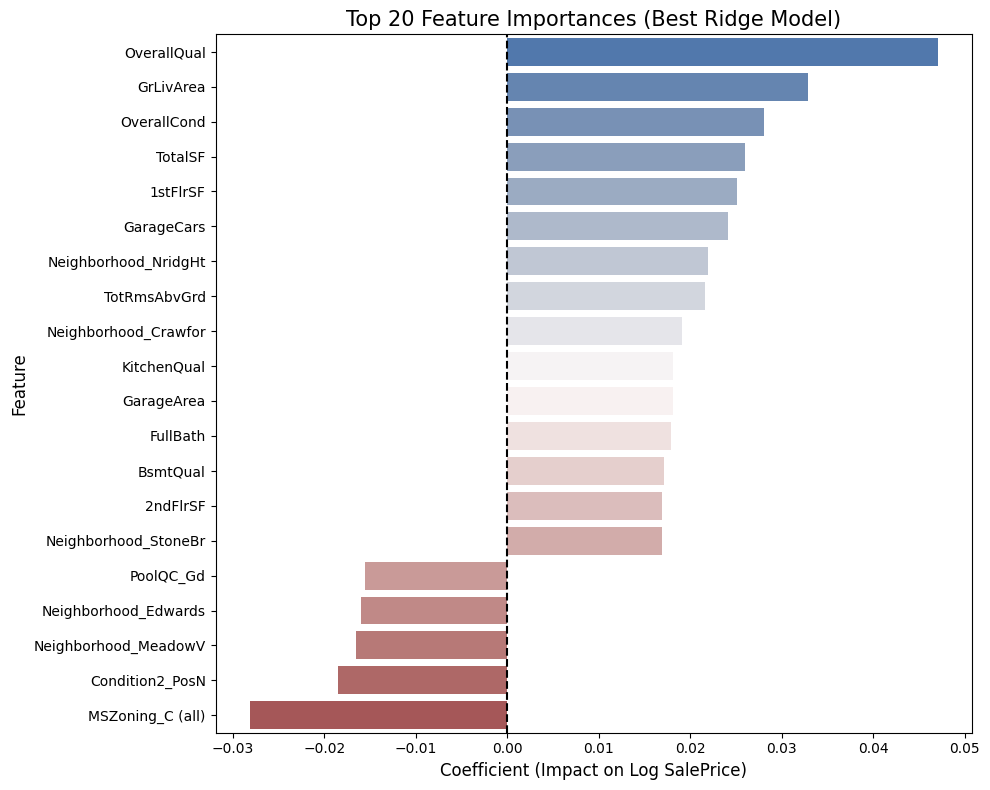

In [33]:
best_ridge_model = grid_ridge.best_estimator_['ridge']

# 特徴量の重要度の表示
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge_model.coef_
})

# 影響力の大きい特徴量を抜粋
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top20_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# 実際の係数の大きさ順で並び替え
top20_features = top20_features.sort_values(by='Coefficient', ascending=False)

# 可視化
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top20_features, palette="vlag")
plt.title('Top 20 Feature Importances (Best Ridge Model)', fontsize=15)
plt.xlabel('Coefficient (Impact on Log SalePrice)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [34]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# グリッドサーチ
param_grid_lgb = {
    'num_leaves': [15, 31, 63],
    'max_depth': [2, 3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500, 700]
}

# 勾配ブースティング
lgb_base = lgb.LGBMRegressor(random_state=42, verbose=-1)

grid_lgb = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid_lgb,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train, y_train)

# 最良の結果を取得
best_lgb_rmse = -grid_lgb.best_score_

print(f"Tuned LightGBM    : {best_lgb_rmse:.5f}")

for key, value in grid_lgb.best_params_.items():
    print(f"{key:<15}: {value}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Tuned LightGBM    : 0.12964
learning_rate  : 0.05
max_depth      : 2
n_estimators   : 700
num_leaves     : 15
